In [2]:
#import the required libraries
import pandas as pd
import numpy as np

In [3]:
#load the dataset
df = pd.read_csv('Dataset for Data Analytics.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.dtypes

Rows: 1200, Columns: 14


OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

In [4]:
#display the first 5 rows of the dataset
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
#Missing values in the dataset
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
#Filling the missing values in the 'CouponCode' column with 'No Coupon Code'
df['CouponCode'] = df['CouponCode'].fillna('No Coupon Code')

print("Missing values after filling the missing values in the 'CouponCode' column:", df['CouponCode'].isnull().sum())

Missing values after filling the missing values in the 'CouponCode' column: 0


In [7]:
#outliers in the dataset
def detect_outliers_iqr(series):
    """Return (lower_bound, upper_bound, boolean_mask_of_outliers)."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    is_outlier = (series < lower_bound) | (series > upper_bound)
    return lower_bound, upper_bound, is_outlier

In [8]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

for col in numeric_cols:
    lower, upper, outlier_mask = detect_outliers_iqr(df[col])
    n_outliers = outlier_mask.sum()
    print(f"{col:12s} -> bounds [{lower:.2f}, {upper:.2f}], outliers found: {n_outliers}")

    if n_outliers > 0:
        # "Neutralize" by capping (clipping) values to the bounds instead of deleting rows —
        # this keeps the order in the dataset (we don't lose customer/product info) while
        # stopping it from skewing the model.
        df[col] = df[col].clip(lower=lower, upper=upper)

Quantity     -> bounds [-1.00, 7.00], outliers found: 0
UnitPrice    -> bounds [-317.20, 1024.83], outliers found: 0
ItemsInCart  -> bounds [-0.50, 11.50], outliers found: 0
TotalPrice   -> bounds [-1341.41, 3330.41], outliers found: 8


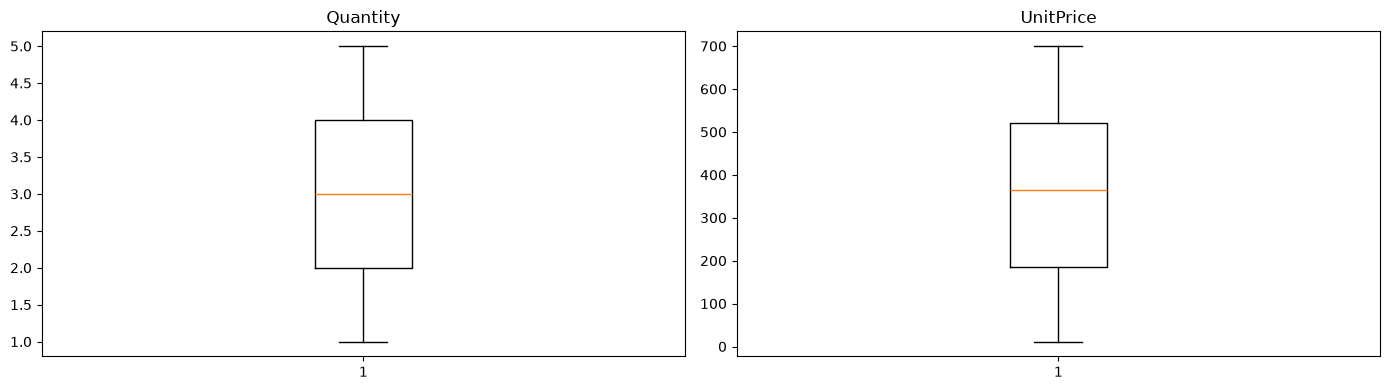

In [9]:
# Visualize the distributions of the numeric columns after outlier treatment
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [10]:
# Feature Engineering: Extracting Month, Day, and Weekend Indicator from Date
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")

df["OrderMonth"] = df["Date"].dt.month
df["OrderDay"] = df["Date"].dt.day
df["isweekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

In [11]:
df["AveragePrice"] = df["TotalPrice"] / df["ItemsInCart"]

In [12]:
df["HasCoupon"] = (df["CouponCode"] != "No Coupon Code").astype(int)

In [13]:
df["IsCancelledOrReturned"] = df["OrderStatus"].isin(["Cancelled", "Returned"]).astype(int)

In [14]:
new_columns = ["OrderMonth", "OrderDay", "isweekend", "AveragePrice", "HasCoupon", "IsCancelledOrReturned"]
df[new_columns].head()  

,OrderMonth,OrderDay,isweekend,AveragePrice,HasCoupon,IsCancelledOrReturned
0,1,4,0,407.585714,1,0
1,8,23,0,100.900000,1,0
2,2,27,0,344.175000,1,1
3,10,15,1,54.638000,1,1
4,5,8,0,313.005000,1,0


In [15]:
output_path = "processed_dataset.csv"
df.to_csv(output_path, index=False)

print(f"Processed dataset saved to {output_path}")
print(f"Final shape: Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Processed dataset saved to processed_dataset.csv
Final shape: Rows: 1200, Columns: 20
